Calculating Financial Compound Interest...


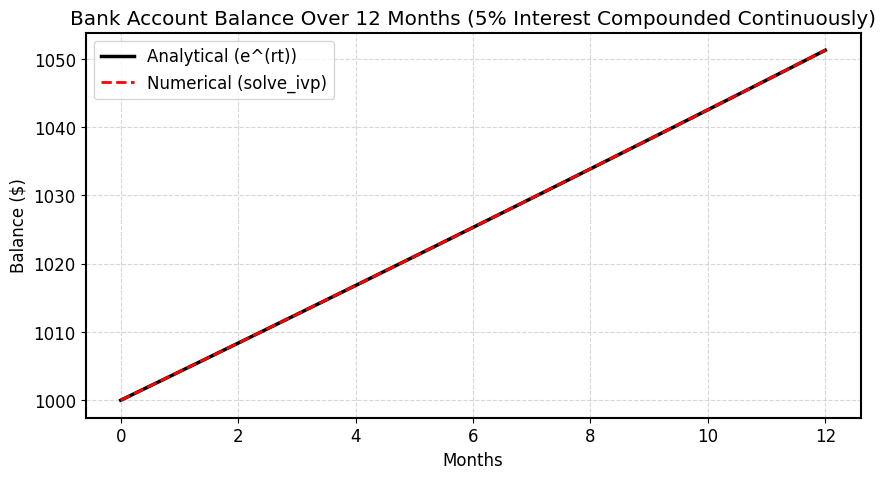

Calculating Radioactive Decay...


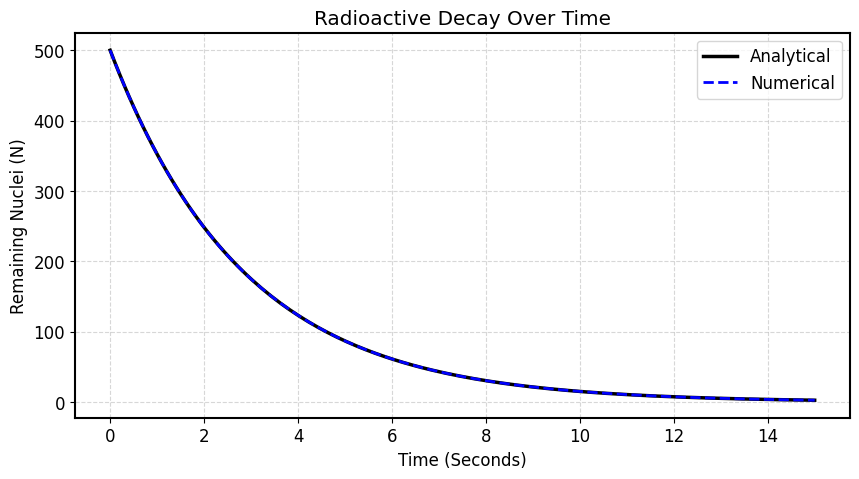

Calculating Logistic Bunny Population...


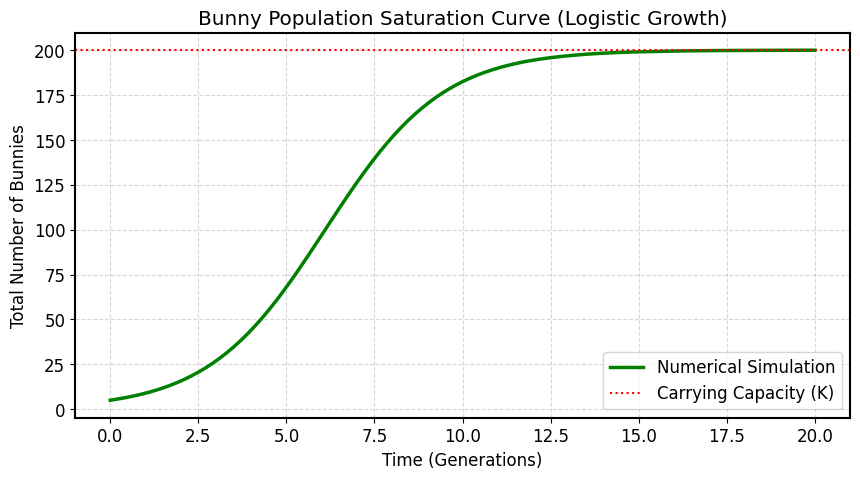

Calculating Thermal Runaway...


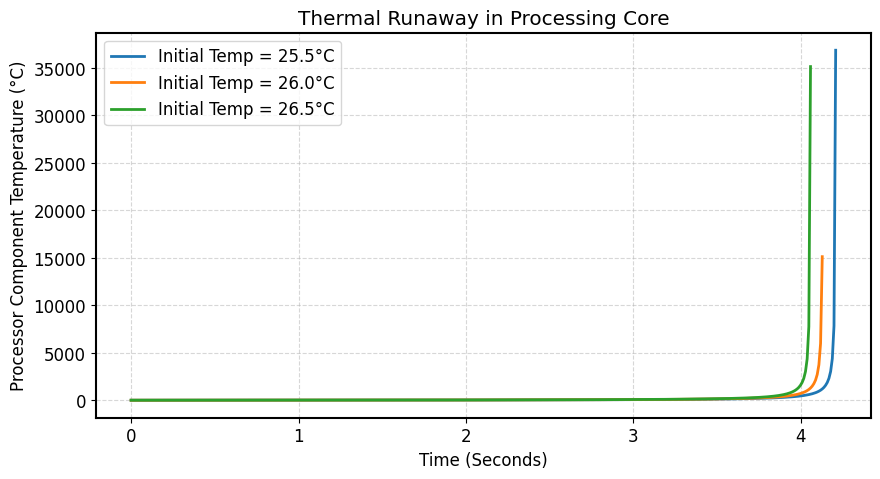

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Set global plotting styles for clean, readable figures (mimicking your MATLAB setup)
plt.rcParams.update({'font.size': 12, 'axes.linewidth': 1.5, 'figure.figsize': (10, 5)})

# =============================================================================
# EXAMPLE 1: Bank Account Compound Interest (Continuous Growth)
# Equation: dM/dt = r * M  => Analytical: M(t) = M0 * exp(r * t)
# =============================================================================
print("Calculating Financial Compound Interest...")

# Parameters
r = 0.05       # 5% annual interest rate
M0 = 1000.0    # Initial balance ($1000)
t_span = (0, 1) # 1 Year timespan
t_eval = np.linspace(0, 1, 100) # Evaluate smoothly across the year

# ODE function for numerical solver
def bank_interest(t, M, r):
    return [r * M[0]]

# Numerical solution (ode45 equivalent)
sol_bank = solve_ivp(bank_interest, t_span, [M0], args=(r,), t_eval=t_eval)

# Analytical solution
M_analytical = M0 * np.exp(r * t_eval)

# Plotting
fig, ax = plt.subplots()
ax.plot(t_eval * 12, M_analytical, '-k', linewidth=2.5, label='Analytical (e^(rt))')
ax.plot(sol_bank.t * 12, sol_bank.y[0], '--r', linewidth=2, label='Numerical (solve_ivp)')
ax.set_title("Bank Account Balance Over 12 Months (5% Interest Compounded Continuously)")
ax.set_xlabel("Months")
ax.set_ylabel("Balance ($)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.show()


# =============================================================================
# EXAMPLE 2: Radioactive Decay (Negative Linear Growth)
# Equation: dN/dt = -λ * N => Analytical: N(t) = N0 * exp(-λ * t)
# =============================================================================
print("Calculating Radioactive Decay...")

lam = 0.35     # Decay constant (high decay rate)
N0 = 500.0     # Initial number of radioactive nuclei
t_span_decay = (0, 15)
t_eval_decay = np.linspace(0, 15, 150)

def radioactive_decay(t, N, lam):
    return [-lam * N[0]]

sol_decay = solve_ivp(radioactive_decay, t_span_decay, [N0], args=(lam,), t_eval=t_eval_decay)
N_analytical = N0 * np.exp(-lam * t_eval_decay)

fig, ax = plt.subplots()
ax.plot(t_eval_decay, N_analytical, '-k', linewidth=2.5, label='Analytical')
ax.plot(sol_decay.t, sol_decay.y[0], '--b', linewidth=2, label='Numerical')
ax.set_title("Radioactive Decay Over Time")
ax.set_xlabel("Time (Seconds)")
ax.set_ylabel("Remaining Nuclei (N)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.show()


# =============================================================================
# EXAMPLE 3: Bunny Population with Saturation (Logistic Growth)
# Equation: dP/dt = r*P * (1 - P/K)
# =============================================================================
print("Calculating Logistic Bunny Population...")

r_bunny = 0.6  # Growth rate coefficient
K_bunny = 200  # Carrying capacity of the island environment (Saturation Limit)
P0 = 5         # Start with 5 bunnies
t_span_bunny = (0, 20)
t_eval_bunny = np.linspace(0, 20, 200)

def logistic_population(t, P, r, K):
    return [r * P[0] * (1 - P[0] / K)]

sol_bunny = solve_ivp(logistic_population, t_span_bunny, [P0], args=(r_bunny, K_bunny), t_eval=t_eval_bunny)

fig, ax = plt.subplots()
ax.plot(sol_bunny.t, sol_bunny.y[0], '-g', linewidth=2.5, label='Numerical Simulation')
ax.axhline(K_bunny, color='r', linestyle=':', label='Carrying Capacity (K)')
ax.set_title("Bunny Population Saturation Curve (Logistic Growth)")
ax.set_xlabel("Time (Generations)")
ax.set_ylabel("Total Number of Bunnies")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.show()


# =============================================================================
# EXAMPLE 4: Thermal Runaway in Electronics (Nonlinear Explosive Growth)
# Equation: dT/dt = T^2 - alpha*(T - T_ambient)
# =============================================================================
print("Calculating Thermal Runaway...")

alpha = 0.1         # Heat dissipation constant of the cooling system
T_ambient = 25.0    # Room temperature (°C)
t_span_thermal = (0, 5)
t_eval_thermal = np.linspace(0, 5, 500)

# We will look at three different initial temperatures to showcase stability vs catastrophic explosion
initial_temps = [25.5, 26.0, 26.5]

def thermal_runaway(t, T, alpha, T_amb):
    # T^2 represents internal heat generation from resistance/current leakage
    # alpha*(T - T_amb) represents heat leaving through cooling
    return [0.01 * (T[0]**2) - alpha * (T[0] - T_amb)]

fig, ax = plt.subplots()

for T0 in initial_temps:
    sol_thermal = solve_ivp(thermal_runaway, t_span_thermal, [T0], args=(alpha, T_ambient), t_eval=t_eval_thermal)
    ax.plot(sol_thermal.t, sol_thermal.y[0], linewidth=2, label=f'Initial Temp = {T0}°C')

ax.set_title("Thermal Runaway in Processing Core")
ax.set_xlabel("Time (Seconds)")
ax.set_ylabel("Processor Component Temperature (°C)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Match high-quality MATLAB publication styling
plt.rcParams.update({
    'font.size': 13,
    'axes.linewidth': 2,
    'figure.figsize': (12, 5),
    'lines.linewidth': 2.5
})

# Define a shared smooth timeline mimicking your MATLAB setup
t_start, t_end = 0, 50
t_eval = np.linspace(t_start, t_end, 2000)
t_span = (t_start, t_end)

# Strict accuracy tolerances (Equivalent to MATLAB's odeset RelTol/AbsTol)
high_accuracy_options = {'rtol': 1e-10, 'atol': 1e-11}

print("Initialization complete. Running multi-system simulations...")

Initialization complete. Running multi-system simulations...


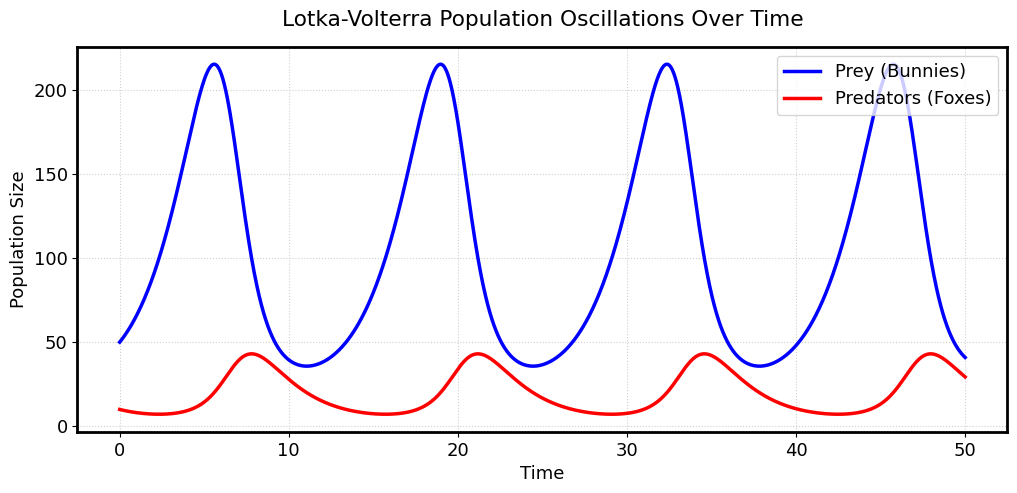

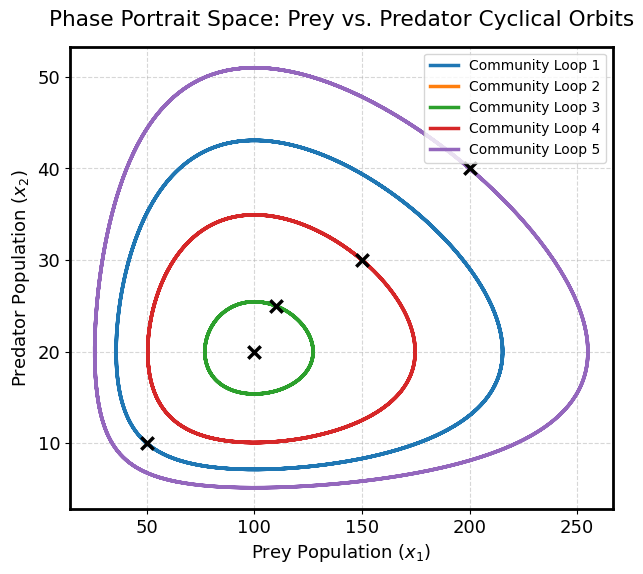

In [3]:
# System Parameters
a, b = 0.5, 0.025  # Prey birth rate / Predator hunting efficiency
c, d = 0.5, 0.005  # Predator natural death rate / Predator reproduction rate from eating

# The Lotka-Volterra System of Equations
def lotka_volterra(t, state, a, b, c, d):
    prey, predator = state[0], state[1]
    d_prey = a * prey - b * prey * predator
    d_predator = -c * predator + d * prey * predator
    return [d_prey, d_predator]

# Ensemble of 5 distinct initial conditions [Prey, Predator]
x0_ensemble = np.array([
    [50, 10],
    [100, 20],
    [110, 25],
    [150, 30],
    [200, 40]
])

# Plot 1: Standard Time History (Using the first starting community)
sol_lv_single = solve_ivp(lotka_volterra, t_span, x0_ensemble[0], args=(a, b, c, d),
                          t_eval=t_eval, **high_accuracy_options)

fig, ax = plt.subplots()
ax.plot(sol_lv_single.t, sol_lv_single.y[0], '-b', label='Prey (Bunnies)')
ax.plot(sol_lv_single.t, sol_lv_single.y[1], '-r', label='Predators (Foxes)')
ax.set_title("Lotka-Volterra Population Oscillations Over Time", pad=15)
ax.set_xlabel("Time")
ax.set_ylabel("Population Size")
ax.legend(loc='upper right')
ax.grid(True, linestyle=":", alpha=0.6)
plt.show()

# Plot 2: The Phase Space Portrait (Prey vs. Predator Orbits)
# This reveals the hidden conservation laws of the system geometry!

fig, ax = plt.subplots(figsize=(7, 6))

for i, x0 in enumerate(x0_ensemble):
    sol_ensemble = solve_ivp(lotka_volterra, t_span, x0, args=(a, b, c, d),
                             t_eval=t_eval, **high_accuracy_options)
    # Plotting Prey on X-axis and Predators on Y-axis
    ax.plot(sol_ensemble.y[0], sol_ensemble.y[1], label=f'Community Loop {i+1}')
    # Mark the starting vector point with an 'X' marker
    ax.scatter(x0[0], x0[1], marker='x', color='black', s=80, zorder=5)

ax.set_title("Phase Portrait Space: Prey vs. Predator Cyclical Orbits", pad=15)
ax.set_xlabel("Prey Population ($x_1$)")
ax.set_ylabel("Predator Population ($x_2$)")
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)
plt.show()

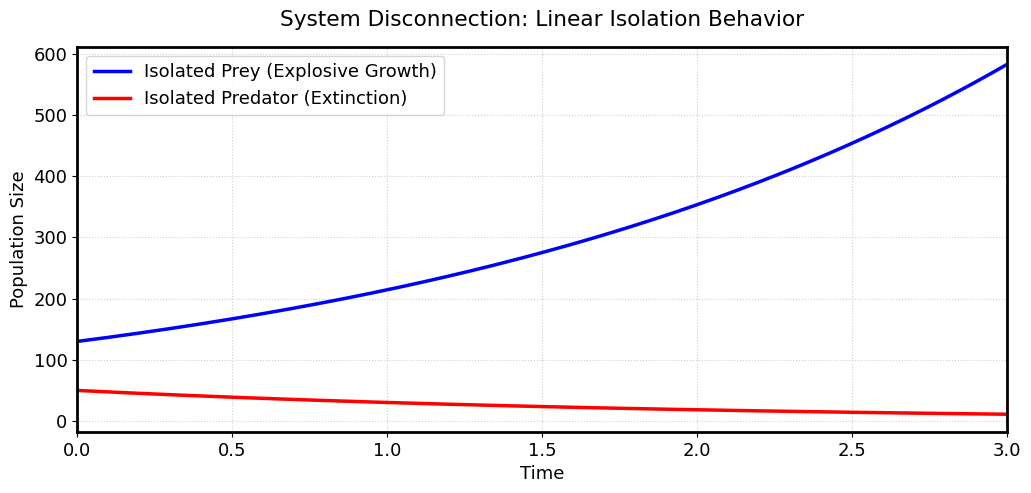

In [4]:
# Modified System: No interaction terms
def isolated_species(t, state, a, c):
    prey, predator = state[0], state[1]
    d_prey = a * prey        # Pure unbounded exponential growth
    d_predator = -c * predator  # Pure exponential decay to extinction
    return [d_prey, d_predator]

x0_isolated = [130, 50]
t_span_short = (0, 3)
t_eval_short = np.linspace(0, 3, 300)

sol_isolated = solve_ivp(isolated_species, t_span_short, x0_isolated, args=(a, c),
                         t_eval=t_eval_short, **high_accuracy_options)

fig, ax = plt.subplots()
ax.plot(sol_isolated.t, sol_isolated.y[0], '-b', label='Isolated Prey (Explosive Growth)')
ax.plot(sol_isolated.t, sol_isolated.y[1], '-r', label='Isolated Predator (Extinction)')
ax.set_title("System Disconnection: Linear Isolation Behavior", pad=15)
ax.set_xlabel("Time")
ax.set_ylabel("Population Size")
ax.set_xlim(0, 3)
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)
plt.show()

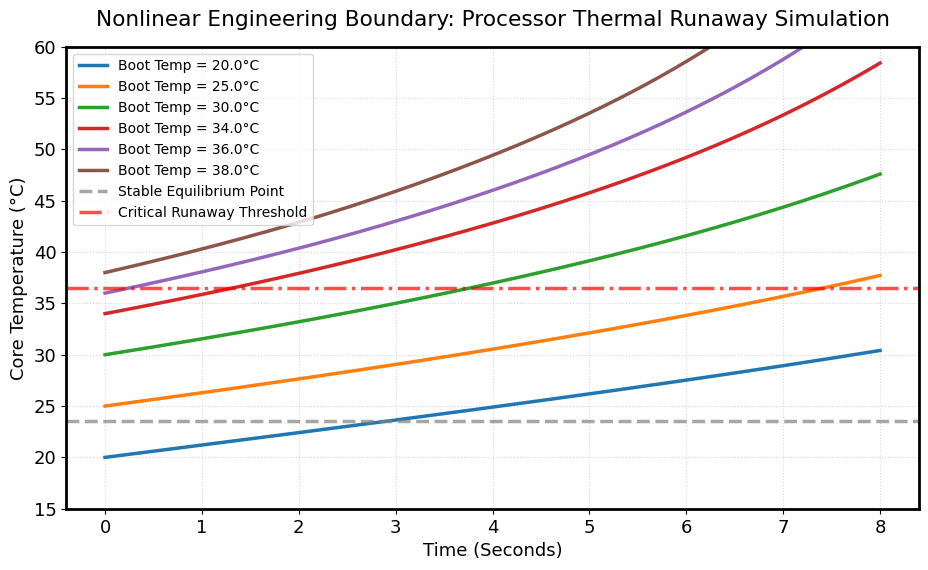

In [5]:
# Engineering Constants
alpha_cool = 0.12    # Efficiency of the cooling heatsink
T_amb = 20.0         # Environmental ambient cleanroom temperature (°C)
t_span_chip = (0, 8)
t_eval_chip = np.linspace(0, 8, 800)

def processor_core_dynamics(t, T, alpha, T_ambient):
    # Heat generated via power leakage (Nonlinear) minus Heat extracted (Linear)
    return [0.003 * (T[0]**2) - alpha * (T[0] - T_ambient)]

# Simulate 6 chips starting at slightly different internal operation temperatures
chip_boot_temps = [20.0, 25.0, 30.0, 34.0, 36.0, 38.0]

fig, ax = plt.subplots(figsize=(11, 6))

for T0 in chip_boot_temps:
    sol_chip = solve_ivp(processor_core_dynamics, t_span_chip, [T0], args=(alpha_cool, T_amb),
                         t_eval=t_eval_chip)

    # If the simulation breaks because the temperature shot to infinity, plot what was caught
    ax.plot(sol_chip.t, sol_chip.y[0], label=f'Boot Temp = {T0}°C')

# Labeling engineering boundaries
ax.axhline(23.5, color='gray', linestyle='--', alpha=0.7, label='Stable Equilibrium Point')
ax.axhline(36.5, color='red', linestyle='-.', alpha=0.7, label='Critical Runaway Threshold')

ax.set_title("Nonlinear Engineering Boundary: Processor Thermal Runaway Simulation", pad=15)
ax.set_xlabel("Time (Seconds)")
ax.set_ylabel("Core Temperature (°C)")
ax.set_ylim(15, 60)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, linestyle=":", alpha=0.5)
plt.show()

Global Banking Simulator Initialized.
Initial Loan: $250,000.00 at 6.0% interest.
Annual Repayment Rate: $12,000.00/year

MILESTONE    | TIME (YEARS)    | NUMERICAL BAL.   | ANALYTICAL BAL.
Initial      | 0.000000        | $250,000.00      | $250,000.00
2 Hours      | 0.000228        | $250,000.68      | $250,000.68
5 Hours      | 0.000571        | $250,001.71      | $250,001.71
Half Day     | 0.001370        | $250,004.11      | $250,004.11
1 Day        | 0.002740        | $250,008.22      | $250,008.22
1 Year       | 1.000000        | $253,091.83      | $253,091.83
10 Years     | 10.000000       | $291,105.94      | $291,105.94
100 Years    | 100.000000      | $20,371,439.67   | $20,371,439.67


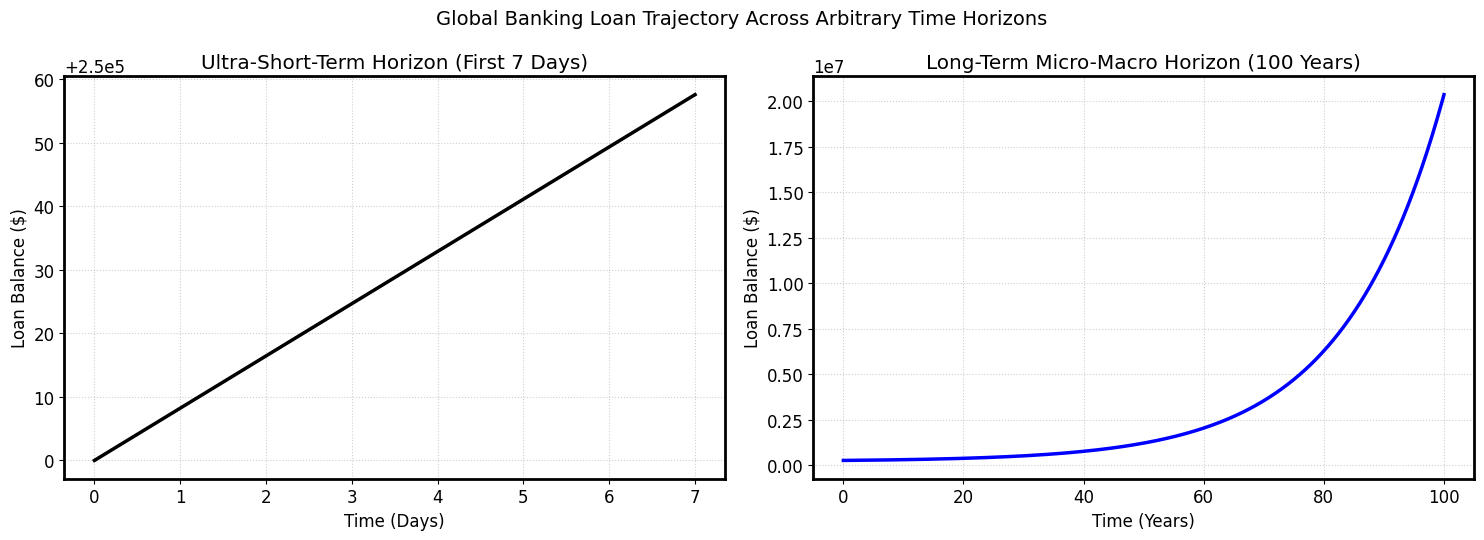

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Match professional MATLAB publication styling from your previous examples
plt.rcParams.update({
    'font.size': 12,
    'axes.linewidth': 2,
    'figure.figsize': (11, 6),
    'lines.linewidth': 2.5
})

# =============================================================================
# 1. DEFINE SYSTEM CONSTANTS & ARBITRARY MILESTONES
# =============================================================================
# Initial Loan Parameters
M0 = 250000.0      # Initial Loan Value (e.g., $250,000 mortgage)
r_interest = 0.06  # 6% annual interest rate
P_payment = 12000.0 # Repayment rate of $12,000 per year (set to 0 for pure accumulation)

# Define time conversion constants (1 Year base unit)
HOURS_IN_YEAR = 24 * 365
DAYS_IN_YEAR = 365

# Map of arbitrary milestones requested: { "Display Name": Time_In_Years }
milestones = {
    "2 Hours":     2 / HOURS_IN_YEAR,
    "5 Hours":     5 / HOURS_IN_YEAR,
    "Half Day":    0.5 / DAYS_IN_YEAR,
    "1 Day":       1.0 / DAYS_IN_YEAR,
    "1 Year":      1.0,
    "10 Years":    10.0,
    "100 Years":   100.0
}

# Sort milestones chronologically for the numerical solver pipeline
sorted_milestones = sorted(milestones.items(), key=lambda x: x[1])
max_time = sorted_milestones[-1][1]  # 100 years

print(f"Global Banking Simulator Initialized.")
print(f"Initial Loan: ${M0:,.2f} at {r_interest*100}% interest.")
print(f"Annual Repayment Rate: ${P_payment:,.2f}/year\n")

# =============================================================================
# 2. THE CONTINUOUS BANKING SYSTEM ODE
# =============================================================================
def global_loan_dynamics(t, M, r, P):
    # dM/dt = interest accrued minus payments made
    return [r * M[0] - P]

# Extract raw time targets for evaluation points
t_targets = [val for name, val in sorted_milestones]
# Prepend 0 to make sure the solver catches the initial state explicitly
t_eval_points = np.array([0.0] + t_targets)

# Run high-precision numerical solver (Equivalent to MATLAB's odeset option)
sol = solve_ivp(
    global_loan_dynamics,
    (0.0, max_time),
    [M0],
    args=(r_interest, P_payment),
    t_eval=t_eval_points,
    rtol=1e-12,
    atol=1e-14
)

# =============================================================================
# 3. ANALYTICAL SOLUTION FOR VERIFICATION
# =============================================================================
# Exact mathematical solution via calculus: M(t) = (M0 - P/r)*e^(rt) + P/r
def analytical_loan(t, M0, r, P):
    if r == 0:
        return M0 - P * t
    return (M0 - P / r) * np.exp(r * t) + P / r

# =============================================================================
# 4. PRINT SPECIFIC MILESTONE REPORT
# =============================================================================
print("=" * 65)
print(f"{'MILESTONE':<12} | {'TIME (YEARS)':<15} | {'NUMERICAL BAL.':<16} | {'ANALYTICAL BAL.'}")
print("=" * 65)
print(f"{'Initial':<12} | {0.0:<15.6f} | ${M0:<15,.2f} | ${M0:,.2f}")

# Map solver outputs back to our human-readable milestone dictionary
for name, t_val in sorted_milestones:
    # Find index matching this time target in solver output array
    idx = np.argmin(np.abs(sol.t - t_val))
    num_bal = sol.y[0][idx]
    ana_bal = analytical_loan(t_val, M0, r_interest, P_payment)

    print(f"{name:<12} | {t_val:<15.6f} | ${num_bal:<15,.2f} | ${ana_bal:,.2f}")
print("=" * 65)

# =============================================================================
# 5. VISUALIZING THE TIME SCALES (MULTI-PLOT GRAPH)
# =============================================================================
# Since 2 hours and 100 years cannot look good on the same line plot,
# we create a split-view system: Short-term vs Long-term horizons
t_smooth_short = np.linspace(0, 7 / DAYS_IN_YEAR, 500) # 1 Week view
t_smooth_long = np.linspace(0, 100, 1000)              # 100 Year view

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Plot 1: Ultra-Short-Term Horizon (First few days)
ax1.plot(t_smooth_short * DAYS_IN_YEAR, analytical_loan(t_smooth_short, M0, r_interest, P_payment), '-k', label='Analytical')
ax1.set_title("Ultra-Short-Term Horizon (First 7 Days)")
ax1.set_xlabel("Time (Days)")
ax1.set_ylabel("Loan Balance ($)")
ax1.grid(True, linestyle=":", alpha=0.6)

# Plot 2: Long-Term Horizon (Up to a Century)
ax2.plot(t_smooth_long, analytical_loan(t_smooth_long, M0, r_interest, P_payment), '-b', label='Numerical Path')
ax2.set_title("Long-Term Micro-Macro Horizon (100 Years)")
ax2.set_xlabel("Time (Years)")
ax2.set_ylabel("Loan Balance ($)")
ax2.grid(True, linestyle=":", alpha=0.6)

plt.suptitle("Global Banking Loan Trajectory Across Arbitrary Time Horizons", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()